<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.3 Tensão Tangencial Máxima. Círculo de Mohr.
## Problema 8 <a name="PI38"></a>

Considere o estado de tensão na vizinhança do ponto $P$ que se representa na Figura.

[a)](#A) Escreva o tensor das tensões para este ponto e para o referencial $S(O,\vec{\imath},\,\vec{\jmath},\,\vec{k})$ indicado. Obtenha também o tensor esférico e o tensor desviador no ponto.

[b)](#B) Desenhe o círculo de Mohr para o estado de tensão representado, assinalando os pontos correspondentes às faces respectivamente perpendiculares aos eixos $x$ e $y$, o valor da tensão tangencial máxima e as tensões principais do estado de tensão.

[c)](#C) Determine as direcções principais do estado de tensão em P e escreva a matriz de transformação do referencial original $S(O,\vec{\imath},\,\vec{\jmath},\,\vec{k})$ para o referencial principal $S(O,\vec{e}_\mathrm{I},\vec{e}_\mathrm{II},\vec{e}_\mathrm{III})$.

[d)](#C) Considere agora que $\sigma_{zz}$ é diferente de zero e determine a gama de valores de $\sigma_{zz}$ para a qual a tensão tangencial máxima se mantém inferior a 160 MPa.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au03/Au03_P008_i1.jpg" width="400" height="150">


## Resolução

#### a) Escreva o tensor das tensões para este ponto e para o referencial $S(O,\vec{\imath},\,\vec{\jmath},\,\vec{k})$ indicado. Obtenha também o tensor esférico e o tensor desviador no ponto.<a name="A"></a>

([enunciatum](#PI38))

Num sistema de coordenadas $S_0(0,\vec{\imath},\vec{\jmath},\vec{k})$ a matriz do tensor das tensões num ponto matarial
$P$ vem expresso por:

\begin{equation*}
\begin{aligned}
\sigma_{ji} &=
\begin{bmatrix}
\sigma_{xx} & \sigma_{yx} & \sigma_{zx} \\
\sigma_{xy} & \sigma_{yy} & \sigma_{zy} \\
\sigma_{xz} & \sigma_{yz} & \sigma_{zz}
\end{bmatrix}
\begin{bmatrix}
n_1 \\ n_2 \\ n_3
\end{bmatrix}
\end{aligned}
\end{equation*}

em que, cada coluna da matriz $\underline{\underline{\sigma}}^T(P)$ é obtida pelas componentes cartesianas dos vetores
tensão, $\vec{t}(\vec{e}_j)$, que atuam nas facetas normais aos eixos coordenados do sistema ortonormado e direto:

\begin{equation*}
\begin{cases}
\vec{t}(\vec{\imath}) = \sigma_{xx} \vec{\imath} + \sigma_{xy} \vec{e}_2 + \sigma_{xz} \vec{e}_3\\
\vec{t}(\vec{\jmath}) = \sigma_{yx} \vec{\imath} + \sigma_{yy} \vec{e}_2 + \sigma_{yz} \vec{e}_3\\
\vec{t}(\vec{k}) = \sigma_{zx} \vec{k} + \sigma_{zy} \vec{e}_2 + \sigma_{zz} \vec{e}_3\\
\end{cases}
\end{equation*}

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def versor(n1,n2,n3):
    return np.array([n1, n2, n3])

def TensorTensoes(s11,s12,s13,s22,s23,s33):
    s21 = s12; s31 = s13; s32 = s23
    return np.array([[s11,s12,s13], [s21,s22,s23], [s31,s32,s33]])

tt0 = TensorTensoes(180,80,0,60,0,0)
print('tt0 = \n',tt0)

tt0 = 
 [[180  80   0]
 [ 80  60   0]
 [  0   0   0]]


O tensor das tensões pode ser decomposto considerando:

\begin{equation*}
[\sigma] = [\sigma]_M + [\sigma]_D
\end{equation*}

em que:

- $[\sigma]_M$ é o tensor esférico ou hidrostático defenido por:

\begin{equation*}
[\sigma]_M = \begin{bmatrix}
\sigma_m & 0 & 0 \\
0 & \sigma_m & 0\\
0 & 0 & \sigma_m \\
\end{bmatrix}
\end{equation*}

com $\sigma_m = \sigma_{ii}/3 = (\sigma_{11} + \sigma_{22} +\sigma_{33})/3$

- $[\sigma]_D$ é o tensor desviador dado por:

\begin{equation*}
[\sigma]_D = \begin{bmatrix}
\sigma_{11}-\sigma_{m} & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_{22}-\sigma_{m} & \sigma_{23}\\
\sigma_{31} & \sigma_{32} & \sigma_{33}-\sigma_{m} \\
\end{bmatrix}
\end{equation*}

In [51]:
s11 = tt0[0,0]
s22 = tt0[1,1]
s33 = tt0[2,2]

sigma_m = (s11 + s22 + s33)/3
# or : sigma_m = np.trace(tt0)/3

def tensorEsferico(sm): return np.array([[sm,0,0],[0,sm,0],[0,0,sm]])

print('\nsigma_m = sigma_ii /3 = ',sigma_m)
tEsf = tensorEsferico(sigma_m)
print('\nTensor esférico = \n',tEsf)

tDesv = tt0 - tEsf
print('\nTensor desviador = \n',tDesv)


sigma_m = sigma_ii /3 =  80.0

Tensor esférico = 
 [[80.  0.  0.]
 [ 0. 80.  0.]
 [ 0.  0. 80.]]

Tensor desviador = 
 [[100.  80.   0.]
 [ 80. -20.   0.]
 [  0.   0. -80.]]


#### b) Desenhe o círculo de Mohr para o estado de tensão representado, assinalando os pontos correspondentes às faces respectivamente perpendiculares aos eixos $x$ e $y$, o valor da tensão tangencial máxima e as tensões principais do estado de tensão.<a name="B"></a>

([enunciatum](#PI38))

A variação das componentes cartesianas do tensor das tensões com uma transformação arbitrária do referencial, cujas
normais definem facetas ortonormadas num determinado ponto material, é obtida por leis de transformação de um tensor de
segunda ordem simétrico, que, em estado plano de tensão, se escrever por:

\begin{equation*}
\begin{aligned}
[\sigma]_1 &= [T_{01}]\,[\sigma]_0\,[T_{01}]^{\mathrm{T}}
\end{aligned}
\end{equation*}

cujo desenvolvimento algébrico conduz as seguintes relações explicitas,

\begin{equation*}
\begin{aligned}
\sigma_{y'y'} &= \frac{\sigma_{yy} + \sigma_{zz} }{2} + \frac{\sigma_{yy} - \sigma_{zz} }{2} \cos2\theta -
\tau_{yz}\sin2\theta \\
\sigma_{z'z'} &= \frac{\sigma_{yy} + \sigma_{zz} }{2} - \frac{\sigma_{yy} - \sigma_{zz} }{2} \cos2\theta -
\tau_{yz}\sin2\theta \\
\tau_{y'z'} &= \frac{\sigma_{zz} - \sigma_{yy} }{2} \sin2\theta + \tau_{yz}\cos2\theta \\
\end{aligned}
\end{equation*}

--------------------------
Equações de transformação:
--------------------------

PLANO x-y:

Tensões (normais) principais: -------------------------------------------
angPrincipal 1 (deg) = 26.57
tens xx plano principal [1] (MPa) = 220.00
tens yy plano principal [1] (MPa) = 20.00
tens xy plano principal [1] (MPa) = 0.00

angPrincipal 2 (deg) = 116.57
tens xx plano principal [2] (MPa) = 20.00
tens yy plano principal [2] (MPa) = 220.00
tens xy plano principal [2] (MPa) = 0.00

Tensões de corte maximas/mínima: -------------------------------------------
Ângulo tensão corte max (Deg) = -18.43
tens xx - plano  tensão de corte max (MPa) = 120.00
tens yy - plano  tensão de corte max (MPa) = 120.00
tens xy - plano  tensão de corte max (MPa) = 100.00
Ângulo tensão corte min (Deg) = 71.57
tens xx - plano  tensão de corte min (MPa) = 120.00
tens yy - plano  tensão de corte min (MPa) = 120.00
tens xy - plano  tensão de corte min (MPa) = -100.00


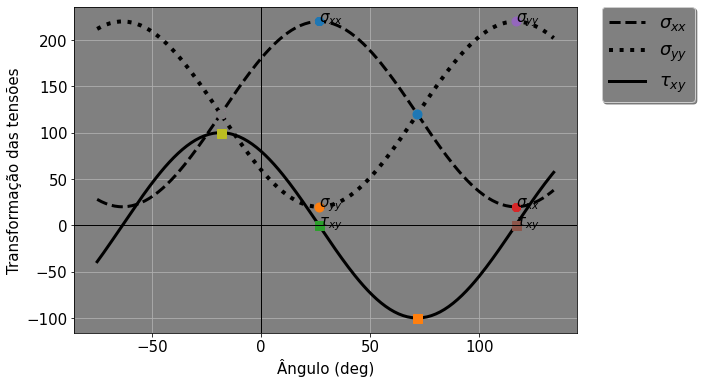

In [52]:
print('--------------------------')
print('Equações de transformação:')
print('--------------------------')

#print('\nMatriz das tensões tt0 = \n',tt0)

def sxx1(sxx,syy,txy,t):
    return (sxx+syy)/2 + (sxx-syy)/2*np.cos(2*t) + txy*np.sin(2*t)

def syy1(sxx,syy,txy,t):
    return (sxx+syy)/2 - (sxx-syy)/2*np.cos(2*t) - txy*np.sin(2*t)

def txy1(sxx,syy,txy,t):
    return (syy-sxx)/2*np.sin(2*t) + txy*np.cos(2*t)

def angPrincipal(sxx,syy,txy):
    return np.arctan(2*txy/(sxx-syy))/2

def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

print('\nPLANO x-y:\n')
sxx = tt0[0,0] # neste caso: x = y; y = z
txy = tt0[0,1]
syy = tt0[1,1]

angt = np.arange(-75,135,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

print('Tensões (normais) principais: -------------------------------------------')
aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal 1 (deg) =','{:.2f}'.format(aprinc))
tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens xx plano principal [1] (MPa) =','{:.2f}'.format(tsxx1))
print('tens yy plano principal [1] (MPa) =','{:.2f}'.format(tsyy1))
print('tens xy plano principal [1] (MPa) =','{:.2f}'.format(ttxy1))

aprinc2 = aprinc + 90
print('\nangPrincipal 2 (deg) =','{:.2f}'.format(aprinc2))
tsxx2 = sxx1(sxx,syy,txy,np.deg2rad(aprinc2))
tsyy2 = syy1(sxx,syy,txy,np.deg2rad(aprinc2))
ttxy2 = txy1(sxx,syy,txy,np.deg2rad(aprinc2))
print('tens xx plano principal [2] (MPa) =','{:.2f}'.format(tsxx2))
print('tens yy plano principal [2] (MPa) =','{:.2f}'.format(tsyy2))
print('tens xy plano principal [2] (MPa) =','{:.2f}'.format(np.abs(ttxy2)))

print('\nTensões de corte maximas/mínima: -------------------------------------------')
aS1 = angS(sxx,syy,txy)/2 # ângulo no espaço físico, radianos
print('Ângulo tensão corte max (Deg) =','{:.2f}'.format(np.rad2deg(aS1)))
tcortexxMa = sxx1(sxx,syy,txy,aS1)
tcorteyyMa = syy1(sxx,syy,txy,aS1)
tcortexyMa = txy1(sxx,syy,txy,aS1)
print('tens xx - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexxMa))
print('tens yy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcorteyyMa))
print('tens xy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexyMa))

aS2 = aS1 + np.pi/2
print('Ângulo tensão corte min (Deg) =','{:.2f}'.format(np.rad2deg(aS2)))
tcortexxMb = sxx1(sxx,syy,txy,aS2)
tcorteyyMb = syy1(sxx,syy,txy,aS2)
tcortexyMb = txy1(sxx,syy,txy,aS2)
print('tens xx - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexxMb))
print('tens yy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcorteyyMb))
print('tens xy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexyMb))

# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

font = {'size' : 15}
plt.rc('font', **font)
fig, ax = plt.subplots(figsize=(9,6))
plt.rcParams['axes.facecolor']='gray'
# plots
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=3)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=4)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
# points: principal stresses
ax.plot(aprinc, tsxx1, '8', markersize=9), ax.text(aprinc, tsxx1,r'$\sigma_{xx}$')
ax.plot(aprinc, tsyy1, 'o', markersize=9), ax.text(aprinc, tsyy1,r'$\sigma_{yy}$')
ax.plot(aprinc, ttxy1, 's', markersize=9), ax.text(aprinc, ttxy1,r'$\tau_{xy}$')
ax.plot(aprinc2, tsxx2, '8', markersize=9), ax.text(aprinc2, tsxx2,r'$\sigma_{xx}$')
ax.plot(aprinc2, tsyy2, 'o', markersize=9), ax.text(aprinc2, tsyy2,r'$\sigma_{yy}$')
ax.plot(aprinc2, ttxy2, 's', markersize=9), ax.text(aprinc2, ttxy2,r'$\tau_{xy}$')
# points: critical shear stresses
ax.plot(np.rad2deg(aS1), tcortexxMa, '8', markersize=9)
ax.plot(np.rad2deg(aS1), tcorteyyMa, 'o', markersize=9)
ax.plot(np.rad2deg(aS1), tcortexyMa, 's', markersize=9)
ax.plot(np.rad2deg(aS2), tcortexxMb, '8', markersize=9)
ax.plot(np.rad2deg(aS2), tcorteyyMb, 'o', markersize=9)
ax.plot(np.rad2deg(aS2), tcortexyMb, 's', markersize=9)

ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

Existe um estado plano de tensão com $\sigma_{zz} = \tau_{xz} = \tau_{yz} = 0$. O eixo dos $zz$ é uma direção principal de tensão e
$\sigma_{zz} = 0$ é tensão principal (valor próprio associado a $\vec{k}$).

A análise do círculo de Mohr permite determinar os valores máximos e mínimos das componentes normais das tensões
(tensões principais) num determinado plano de análise de acordo com as seguintes expressões:

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{max/min} \equiv \sigma_\mathrm{I/III} &= \sigma_\mathrm{médio} \pm R \\
&= \frac{\sigma_{yy} + \sigma_{zz}}{2} \pm  \sqrt{\left(\frac{\sigma_{yy}-\sigma_{zz}}{2}\right)^2 +
\tau_{yz}^2 }
\end{aligned}
\end{equation*}

No espaço das tensões da circunferência de Mohr ($\sigma,\tau$) os ângulos principais obtêm-se de acordo com a seguinte
relação geométrica:

\begin{equation*}
\begin{aligned}
2\theta_{P1} &= \arctan \left(\frac{2\tau_{xz}}{\sigma_{xx}-\sigma_{zz}}\right) \\
2\theta_{P2} &= 2\theta_{P1} + 2(90^\circ)\\
\end{aligned}
\end{equation*}

Uma vez que o sistema de coordenadas de referência e o principal têm o eixo dos $zz$ em comum (i.e., a transformação é
caraterizada por uma rotação em torno de um eixo comum), a transformação é completamente definida pelo ângulo de
rotação ($\theta_\mathrm{P}$).

\begin{equation*}
\begin{array}{ccccc}
&& \vec{\imath} & \vec{\jmath} & \vec{k} \\
&& \downarrow & \downarrow & \downarrow \\
\vec{\imath}_\mathrm{P} & \rightarrow & \vec{\imath}_\mathrm{P} \cdot \vec{\imath}
& \vec{\imath}_\mathrm{P} \cdot \vec{\jmath} & \vec{\imath}_\mathrm{P} \cdot \vec{k} \\
\vec{\jmath}_\mathrm{P} & \rightarrow & \vec{\jmath}_\mathrm{P} \cdot \vec{\imath}
& \vec{\jmath}_\mathrm{P} \cdot \vec{\jmath} & \vec{\jmath}_\mathrm{P} \cdot \vec{k} \\
\vec{k}_\mathrm{P} & \rightarrow & \vec{k}_\mathrm{P} \cdot \vec{\imath} &
\vec{k}_\mathrm{P} \cdot \vec{\jmath} & \vec{k}_\mathrm{P} \cdot \vec{k}
\end{array}
\quad\quad\quad\quad
\begin{aligned}
\text{}\\
\begin{cases}
\vec{\imath}_\mathrm{P} &= \cos\theta_\mathrm{P} \vec{\imath} + \sin\theta_\mathrm{P} \vec{\jmath} + 0 \vec{k} \\
\vec{\jmath}_\mathrm{P} &= -\sin\theta_\mathrm{P} \vec{\imath} +  \cos\theta_\mathrm{P} \vec{\jmath} + 0 \vec{k} \\
\vec{k}_\mathrm{P} &= 0 \vec{\imath} + 0 \vec{\jmath} + 1 \vec{k} \\
\end{cases}
\end{aligned}
\end{equation*}

em forma matricial,

\begin{equation*}
\begin{bmatrix}
\vec{\imath}_\mathrm{P} \\ \vec{\jmath}_\mathrm{P} \\ \vec{k}_\mathrm{P}
\end{bmatrix} =
\begin{bmatrix}
\cos\theta_\mathrm{P} & \sin\theta_\mathrm{P} & 0 \\
-\sin\theta_\mathrm{P} & \cos\theta_\mathrm{P} & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\begin{bmatrix}
\vec{\imath}  \\ \vec{\jmath}  \\ \vec{k}
\end{bmatrix}
\end{equation*}

In [53]:
def angP(s11,s22,s12): return np.arctan((2*s12)/(s11-s22))

print('PLANO x-y:\n')
sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]

aP1 = angP(sxx,syy,sxy)
aP2 = aP1 + np.pi

print('Ângulos das direções principais (tensões principais) ------------')
print('\nNo espaço de Mohr:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\ndet(T) = ',np.linalg.det(MatrTrans))

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)

PLANO x-y:

Ângulos das direções principais (tensões principais) ------------

No espaço de Mohr:
angPI:   53.130  deg |  0.927  radians
angPII:  233.130  deg |  4.069  radians

No espaço fisico:
angPI:   26.565  deg |  0.464  radians
angPII:  116.565  deg |  2.034  radians

Matriz de transformação = 
 [[ 0.894  0.447  0.   ]
 [-0.447  0.894  0.   ]
 [ 0.     0.     1.   ]]

det(T) =  1.0

Vetores principais:
eI =  [0.894 0.447 0.   ]
eII =  [-0.447  0.894  0.   ]
eIII =  [0. 0. 1.]


A análise do círculo de Mohr permite determinar os valores máximos e mínimos das componentes de
corte das tensões num determinado plano de análise. Considere-se esse plano $Oyz$, vem então:

\begin{equation*}
\begin{aligned}
\tau_\mathrm{max/min} & \equiv R = \pm \sqrt{\left(\frac{\sigma_{yy}-\sigma_{zz}}{2}\right)^2 +
\tau_{yz}^2 }
\end{aligned}
\end{equation*}

In [54]:
# plano x-y
sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]

Raio = np.sqrt(((sxx-syy)/2)**2 + sxy**2)

tau_max = Raio
print('tau_max = ','{:.2f}'.format(tau_max),' MPa')
tau_min = -Raio
print('tau_min = ','{:.2f}'.format(tau_min),' MPa')

tau_max =  100.00  MPa
tau_min =  -100.00  MPa


Os ângulos que o eixo perpendicular ao plano onde ocorre a tensão tangencial máxima faz
com os eixos do referencial $xyz$ é dado por:

\begin{equation*}
\begin{aligned}
2\theta_{S} &= \arctan \left(-\frac{\sigma_{xx}-\sigma_{zz}}{2\tau_{xz}}\right) \\[1ex]
\end{aligned}
\end{equation*}

In [55]:
def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

aS1 = angS(sxx,syy,sxy)
aS2 = aS1 + np.pi

print('Ângulo tensões de corte máxima ------------')
print('\nNo espaço de Mohr:')
print('angSI:  ','{:.3f}'.format(np.rad2deg(aS1)),' deg | ','{:.3f}'.format(aS1),' radians')
print('angSII: ','{:.3f}'.format(np.rad2deg(aS2)),' deg | ','{:.3f}'.format(aS2),' radians')

aSI = aS1/2
aSII = aS2/2

print('\nNo espaço fisico:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aSI)),' deg | ','{:.3f}'.format(aSI),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aSII)),' deg | ','{:.3f}'.format(aSII),' radians')

Ângulo tensões de corte máxima ------------

No espaço de Mohr:
angSI:   -36.870  deg |  -0.644  radians
angSII:  143.130  deg |  2.498  radians

No espaço fisico:
angPI:   -18.435  deg |  -0.322  radians
angPII:  71.565  deg |  1.249  radians


De notar que as direções principias e a direção de tensão de corte máxima fazem entre si um ângulo de 45$^\circ$.

In [56]:
Di = aPI - aSI
print('Di = ',np.rad2deg(Di))

Di =  45.0


Desenvolvendo o método da circunferência de Mohr no plano de tensão $x-y$:


PLANO x-y:

Ponto A ( 180.0 , -80.0 )
Ponto B ( 60.0 , 80.0 )
  Tensão normal mínima:  20.0
  Tensão normal máxima:  220.0
  Tensão normal média :  120.0
Tensão de corte mínima:  -100.0
Tensão de corte máxima:  100.0


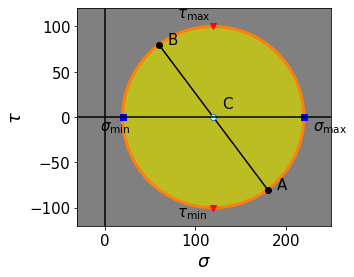

In [57]:
def mohr(S,limits):
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print('Ponto A (','{:.1f}'.format(S11),',','{:.1f}'.format(-S12),')')
    print('Ponto B (','{:.1f}'.format(S22),',','{:.1f}'.format(S12),')')

    print("  Tensão normal mínima: ", np.round(Smin,6))
    print("  Tensão normal máxima: ", np.round(Smax, 6))
    print("  Tensão normal média : ", np.round(center[0], 6))
    print("Tensão de corte mínima: ", np.round(-radius, 6))
    print("Tensão de corte máxima: ", np.round(radius, 6))

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [-S12, S12], 'ko')
    plt.plot([S11, S22], [-S12, S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(S11 + desv, -S12 , 'A')
    plt.text(S22 + desv, S12, 'B')
    plt.text(Smin - 0.25*radius, -0.15*radius, r'$\sigma_\mathrm{min}$')
    plt.text(Smax + desv, -0.15*radius, r'$\sigma_\mathrm{max}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[-30,250],[-120,120]])
print('\nPLANO x-y:\n')
S11 = tt0[0,0]
S12 = tt0[0,1]
S22 = tt0[1,1]
mohr(np.array([[S11, S12],[S12, S22]]),axislim)

#### c) Determine as direcções principais do estado de tensão em P e escreva a matriz de transformação do referencial original $S(O,\vec{\imath},\,\vec{\jmath},\,\vec{k})$ para o referencial principal $S(O,\vec{e}_\mathrm{I},\vec{e}_\mathrm{II},\vec{e}_\mathrm{III})$.<a name="C"></a>

([enunciatum](#PI38))

Algebricamente, as tensões principais obtêm-se da solução da seguinte expressão:

\begin{equation*}
\det(\sigma_{ij}-\sigma\delta_{ij})= 0
\end{equation*}

cuja solução algebrica conduz ao seguinte polinómio caraterístico associado ao tensor das tensões:

\begin{equation*}
\sigma^3 - I_1\sigma^2 + I_2\sigma - I_3 = 0
\end{equation*}

em que $I_i$ ($i=1,2,3$) representam os invariantes do tensor das tensões. Os invariantes vêm expressos em função das
componentes cartesianas de $\sigma_{ij}$ por:

\begin{equation*}
\begin{aligned}
I_1 &= \mathrm{Tr}(\sigma_{ij}) \\
I_2 &= \frac{1}{2}\left[ \mathrm{Tr}(\sigma_{ij})^2 - \mathrm{Tr}(\sigma_{ij}^2) \right] =
\frac{1}{2}\left( \sigma_{ii}\sigma_{jj} - \sigma_{ij}\sigma_{ji} \right) \\
& =
\begin{vmatrix}
\sigma_{11} & \sigma_{12} \\
\sigma_{21} & \sigma_{22} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{11} & \sigma_{13} \\
\sigma_{31} & \sigma_{33} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{22} & \sigma_{23} \\
\sigma_{32} & \sigma_{33} \\
\end{vmatrix} \\\\
I_3 &= \mathrm{det}(\sigma_{ij}) \\
\end{aligned}
\end{equation*}

In [58]:
I1 = np.trace(tt0)
print('\n1º Invariante, I1:', '{:.1f}'.format(I1))

I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print('2º Invariante, I2 :', '{:.1f}'.format(I2))

I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.1f}'.format(I3))

print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('\n Numpy : roots = ',valpropriosN)
valpropriosN = np.sort(valpropriosN)
sIII = valpropriosN[0]
sII = valpropriosN[1]
sI = valpropriosN[2]
print('\n Tensão principal (valor próprio) sI ','{:.2f}'.format(sI))
print('Tensão principal (valor próprio) sII ','{:.2f}'.format(sII))
print('Tensão principal (valor próprio) sIII ','{:.2f}'.format(sIII))


1º Invariante, I1: 240.0
2º Invariante, I2 : 4400.0
3º Invariante, I3 : 0.0

 Resolucao Numerica - Numpy : ............................

 Numpy : roots =  [220.  20.   0.]

 Tensão principal (valor próprio) sI  220.00
Tensão principal (valor próprio) sII  20.00
Tensão principal (valor próprio) sIII  0.00


\begin{equation*}
(\sigma_{ij} - \sigma_\alpha\delta_{ij})\cdot n_j = 0 \quad \wedge \quad n_i \cdot n_i = 1
\quad (\alpha = \mathrm{I,II,III})
\end{equation*}

In [59]:
from sympy.solvers import solve
from sympy import symbols

d1,d2,d3 = symbols('d1 d2 d3')

def eq1(d1,d2,d3,vp): return (tt0[0,0] - vp)*d1 + tt0[0,1]*d2 + tt0[0,2]*d3
def eq2(d1,d2,d3,vp): return tt0[1,0]*d1 + (tt0[1,1] - vp)*d2 + tt0[1,2]*d3
def eq3(d1,d2,d3,vp): return tt0[2,0]*d1 + tt0[2,1]*d2 + (tt0[2,2] - vp)*d3
def eq4(d1,d2,d3): return d1**2 + d2**2 + d3**2 - 1

def versor(e1,e2,e3): return np.array([e1,e2,e3])

# 1 valor proprio -------------------
print('\nVetor próprio associado a sI = ','{:.2f}'.format(sI),'.............................')
print('\n(i) sistema de equações:')
E1_sI = eq1(d1,d2,d3,sI); print(E1_sI,' = 0')
E2_sI = eq2(d1,d2,d3,sI); print(E2_sI,' = 0')
E3_sI = eq3(d1,d2,d3,sI); print(E3_sI,' = 0')
E4_sI = eq4(d1,d2,d3); print(E4_sI,' = 0')
VetProp1 = solve([E1_sI,E3_sI,E4_sI], [d1,d2,d3], dict=True)
l1 = float(VetProp1[1][d1])
m1 = float(VetProp1[1][d2])
n1 = float(VetProp1[1][d3])
versorI = versor(l1,m1,n1)
print('\n (ii) nI = ','{:.3f}'.format(l1),'e1 +','{:.3f}'.format(m1),'e2 +','{:.3f}'.format(n1),'e3')


Vetor próprio associado a sI =  220.00 .............................

(i) sistema de equações:
-40.0*d1 + 80*d2  = 0
80*d1 - 160.0*d2  = 0
-220.0*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nI =  0.894 e1 + 0.447 e2 + 0.000 e3


In [60]:
# 2 valor proprio -------------------
print('\nVetor próprio associado a sII= ','{:.2f}'.format(sII),' .............................')
print('\n (i) sistema de equações:')
E1_sII = eq1(d1,d2,d3,sII); print(E1_sII,' = 0')
E2_sII = eq2(d1,d2,d3,sII); print(E2_sII,' = 0')
E3_sII = eq3(d1,d2,d3,sII); print(E3_sII,' = 0')
E4_sII = eq4(d1,d2,d3); print(E4_sII,' = 0')
VetProp2 = solve([E1_sII,E2_sII,E3_sII,E4_sII], [d1,d2,d3], dict=True)
l2 = float(VetProp2[0][d1])
m2 = float(VetProp2[0][d2])
n2 = float(VetProp2[0][d3])
versorII = versor(l2,m2,n2)
print('\n (ii) nII = (','{:.3f}'.format(l2),') e1 + (','{:.3f}'.format(m2),') e2 + (','{:.3f}'.format(n2),') e3')


Vetor próprio associado a sII=  20.00  .............................

 (i) sistema de equações:
160.0*d1 + 80*d2  = 0
80*d1 + 40.0*d2  = 0
-20.0*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nII = ( -0.447 ) e1 + ( 0.894 ) e2 + ( 0.000 ) e3


In [61]:
# 3 valor proprio -------------------
print('\nVetor próprio associado a sIII= ','{:.2f}'.format(sIII),' .............................')
print('\n (i) sistema de equações:')
E1_sIII = eq1(d1,d2,d3,sIII); print(E1_sIII,' = 0')
E2_sIII = eq2(d1,d2,d3,sIII); print(E2_sIII,' = 0')
E3_sIII = eq3(d1,d2,d3,sIII); print(E3_sIII,' = 0')
E4_sIII = eq4(d1,d2,d3); print(E4_sIII,' = 0')
VetProp3 = solve([E1_sIII,E2_sIII,E4_sIII], [d1,d2,d3], dict=True)
l3 = float(VetProp3[1][d1])
m3 = float(VetProp3[1][d2])
n3 = float(VetProp3[1][d3])
versorIII = versor(l3,m3,n3)
print('\n (ii) nIII = (','{:.3f}'.format(l3),') e1 + (','{:.3f}'.format(m3),') e2 + (','{:.3f}'.format(n3),') e3')

print('\n Further verifications on the principal unit vectors: ')
print('dot(vp1,vp1) = ','{:.1f}'.format(np.dot(versorI,versorI)))
print('dot(vp2,vp2) = ', '{:.1f}'.format(np.dot(versorII,versorII)))
print('dot(vp3,vp3) = ', '{:.1f}'.format(np.dot(versorIII,versorIII)))
print('dot(vp1,vp2) = ', np.dot(versorI,versorII))
print('dot(vp2,vp3) = ', np.dot(versorII,versorIII))
print('dot(vp1,vp3) = ', '{:.0f}'.format(np.abs(np.dot(versorI,versorIII))))

np.set_printoptions(precision=3)
print('\n Matriz de transformação de S0 para SI (ref. principal): ')

print('\n Àngulo entre eI e x: ')
print('\n theta_P = ','{:.2f}'.format(np.rad2deg(np.arccos(l1))), ' Deg')

mT = np.concatenate((versorI, versorII,versorIII))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.dot(np.transpose(mT),mT))

print('\n det(T) = ','{:.2f}'.format(np.linalg.det(mT)))

print('\nverificacao: ni.ni = 1 ')
eI2 = np.sqrt(np.dot(mT[0,:],mT[0,:]))
print('\nT[0,:] : eI2 = ','{:.2f}'.format(eI2))
eII2 = np.sqrt(np.dot(mT[1,:],mT[1,:]))
print('T[1,:] : eII2 = ','{:.2f}'.format(eII2))
eIII2 = np.sqrt(np.dot(mT[2,:],mT[2,:]))
print('T[2,:] : eII2 = ','{:.2f}'.format(eIII2))


Vetor próprio associado a sIII=  0.00  .............................

 (i) sistema de equações:
180.0*d1 + 80*d2  = 0
80*d1 + 60.0*d2  = 0
0  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nIII = ( 0.000 ) e1 + ( 0.000 ) e2 + ( 1.000 ) e3

 Further verifications on the principal unit vectors: 
dot(vp1,vp1) =  1.0
dot(vp2,vp2) =  1.0
dot(vp3,vp3) =  1.0
dot(vp1,vp2) =  0.0
dot(vp2,vp3) =  0.0
dot(vp1,vp3) =  0

 Matriz de transformação de S0 para SI (ref. principal): 

 Àngulo entre eI e x: 

 theta_P =  26.57  Deg

 [T] = 
 [[ 0.894  0.447  0.   ]
 [-0.447  0.894  0.   ]
 [ 0.     0.     1.   ]]

[T][T]^T = I :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

 det(T) =  1.00

verificacao: ni.ni = 1 

T[0,:] : eI2 =  1.00
T[1,:] : eII2 =  1.00
T[2,:] : eII2 =  1.00


#### d) Considere agora que $\sigma_{zz}$ é diferente de zero e determine a gama de valores de $\sigma_{zz}$ para a qual a tensão tangencial máxima se mantém inferior a 160 MPa.<a name="D"></a>

([enunciatum](#PI38))

Assumindo: $\sigma_{zz} \ne  0$ e $\sigma_{\mathrm{I}}$ = 220 MPa e por definição:

\begin{equation*}
\tau_{\mathrm{\max}} = \frac{\sigma_{\mathrm{I}}-\sigma_{\mathrm{III}}}{2} \le 160~\textrm{MPa}
\end{equation*}


Considerando $\sigma_{\mathrm{I}}$ = 220 MPa e $\sigma_{\mathrm{III}} = \sigma_{zz}$ então:

\begin{equation*}
\tau_{\mathrm{\max}} = \frac{\sigma_{\mathrm{I}}-\sigma_{\mathrm{III}}}{2} =
\frac{220-\sigma_{zz}}{2}
\quad \Leftrightarrow \quad \sigma_{\mathrm{zz}} = -100 \textrm{MPa}
\end{equation*}

ou, outra hipótese $\sigma_{zz}>20 ~\therefore~\sigma_{\mathrm{III}} = 20$ MPa.
Assim, considerando $\sigma_{\mathrm{I}} = \sigma_{zz}$ MPa e
$\sigma_{\mathrm{III}} = 20$ MPa então:

\begin{equation*}
\tau_{\mathrm{\max}} = \frac{\sigma_{\mathrm{I}}-\sigma_{\mathrm{III}}}{2}
= \frac{\sigma_{zz}-20}{2}
\quad \Leftrightarrow \quad \sigma_{zz} = 340 \textrm{MPa}
\end{equation*}

logo: $\sigma_{zz} \in [-100,340]$ MPa.


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
